# 태양광 발전량 예측 — AutoGluon v2 (보완본)

**프로젝트**: 전국 17개 시도 태양광 발전량 예측 + ESS 운영 가치 분석
**버전**: v2 (v1 학습 결과 분석 후 보완)
**환경**: GCP Colab Enterprise (L4 24GB), asia-northeast1
**시간**: 학습 3시간 + 예측 1시간 ≈ 총 4시간

---

## 🎯 v1에서 발견한 문제와 v2의 보완점

| v1 문제 | v2 보완 |
|---|---|
| Chronos2/DeepAR 환경 충돌 → 실패 모델로 시간 안 채움 | 환경 충돌 모델 명시적 제외, 학습 시간 정확히 채움 |
| RecursiveTabular 49% 가중치 → 누적오차로 test MAE 폭증 | RecursiveTabular 제외, DirectTabular만 사용 |
| TFT에 9분만 할당 → MASE 1.94 부진 | TFT max_epochs=100 + context_length 168/336 |
| PatchTST 시도조차 안 됨 | PatchTST 신규 추가 |
| num_val_windows=3 → 분포 shift에 취약 | num_val_windows=5 |
| `Model not specified` 경고 매 step | 예측 시 model 명시 |
| 갭 처리 코드 위치 산만 | 갭 처리 셀 명시 분리 |

## ⚠️ 알려진 한계 (v2에서도 못 푸는 것)

- **2022-12-31 23시간 원본 누락**: raw 데이터 자체 누락. 우회 처리(가짜 covariate)만 가능
- **2023년 분포 shift**: 어떤 모델로도 못 풂. capacity 추정 데이터 없음
- **train 마지막 부분 결측**: 강원도 12월 30일 22행/48행

## 비교 기준선 (XGBoost 통합 모델, v1과 동일)

| 지표 | 값 |
|---|---|
| 단순 평균 MAE | 8.79 (60일치 기준) |
| 가중 MAE | 29.55 |
| 전남 MAE | 75.83 |

## v1 결과 (참고)
| 지표 | 값 |
|---|---|
| WeightedEnsemble validation MASE | 0.496 |
| Test 단순 평균 MAE | 18.21 (XGBoost 2배 악화) |
| Test 가중 MAE | 57.53 |

## v2 목표
- v1과 비교해서 test MAE 개선 여부 확인
- 트랜스포머(TFT, PatchTST)에 충분한 학습 시간 → 의미 있는 성능 평가
- XGBoost(트리 가족) AutoGluon 내에서 추가 검증


## 0. 사전 준비 (이전 노트북에서 했다면 스킵 가능)

### GCS 버킷
- 기존 버킷 `solar-ess-portfolio` 그대로 사용
- 위치: asia-northeast1 (도쿄)
- 데이터 파일이 버킷 **루트에** 있음 (data/ 폴더 안 아님)

### 런타임 템플릿
- L4 (24GB)
- idle shutdown 900분 이상 (이전과 동일)

### 데이터 파일 (이미 업로드돼 있어야 함)
- `gs://solar-ess-portfolio/national_train_ready.csv`
- `gs://solar-ess-portfolio/national_test_ready.csv`
- `gs://solar-ess-portfolio/national_xgb_predictions.csv`
- `gs://solar-ess-portfolio/national_xgb_results.json`


## 1. 환경 변수


In [ ]:
!pip install -q "autogluon.timeseries==1.5.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.8/244.8 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 103.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.9/827.9 kB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install -q "torchvision==0.24.1" "torchaudio==2.9.1" \
    --index-url https://download.pytorch.org/whl/cu128

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 130.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 122.0 MB/s eta 0:00:00


In [ ]:
from importlib.metadata import version

print("=== 환경 검증 ===")
for pkg in ['torch', 'torchvision', 'torchaudio',
            'lightning', 'pytorch-lightning', 'torchmetrics',
            'numpy', 'autogluon.timeseries']:
    try:
        print(f"  {pkg:25s} {version(pkg)}")
    except Exception as e:
        print(f"  {pkg:25s} ❌ 없음")

print("\n=== import 체인 테스트 ===")
import torch
print(f"  torch OK (CUDA={torch.cuda.is_available()})")

import torchvision
print(f"  torchvision OK")

from lightning.pytorch import Trainer
print(f"  lightning OK")

from autogluon.timeseries import TimeSeriesPredictor, TimeSeriesDataFrame
print(f"  AutoGluon OK")

print("\n✅ 모든 검증 통과 — 학습 진행 가능")

=== 환경 검증 ===
  torch                     2.9.1
  torchvision               0.24.1+cu128
  torchaudio                2.9.1+cu128
  lightning                 2.5.6
  pytorch-lightning         2.6.1
  torchmetrics              1.9.0
  numpy                     2.0.2
  autogluon.timeseries      1.5.0

=== import 체인 테스트 ===
  torch OK (CUDA=True)
  torchvision OK
  lightning OK
  AutoGluon OK

✅ 모든 검증 통과 — 학습 진행 가능


In [2]:
# ── 본인 GCP 정보 입력 ─────────────────────────────────────────────
PROJECT_ID  = "energy-ts-forecast"           # ← 본인 GCP 프로젝트 ID
GCS_BUCKET  = "solar-ess-portfolio"       # 버킷 이름 (gs:// 빼고)
REGION      = "asia-northeast1"           # 도쿄
# ──────────────────────────────────────────────────────────────────

# 경로 (파일이 버킷 루트에 있음)
GCS_BASE        = f"gs://{GCS_BUCKET}"
TRAIN_URI       = f"{GCS_BASE}/national_train_ready.csv"
TEST_URI        = f"{GCS_BASE}/national_test_ready.csv"
XGB_PRED_URI    = f"{GCS_BASE}/national_xgb_predictions.csv"
XGB_RESULT_URI  = f"{GCS_BASE}/national_xgb_results.json"
OUT_BASE        = f"{GCS_BASE}/outputs/autogluon_v2"

# AutoGluon 설정
PREDICTION_LENGTH = 24
EVAL_METRIC       = "MASE"
TIME_LIMIT_SEC    = 10800        # 3시간
NUM_VAL_WINDOWS   = 5            # v1의 3 → 5 (분포 shift 완화)
RANDOM_STATE      = 42

# 로깅
import sys
# sys.stdout.reconfigure(encoding="utf-8")
from datetime import datetime, timezone, timedelta
KST = timezone(timedelta(hours=9))
def ts():
    return f"[{datetime.now(KST).strftime('%H:%M:%S')}]"

print(f"{ts()} 환경 변수 설정 완료")
print(f"   PROJECT_ID  : {PROJECT_ID}")
print(f"   GCS_BUCKET  : {GCS_BUCKET}")
print(f"   TIME_LIMIT  : {TIME_LIMIT_SEC // 3600}시간")
print(f"   OUT_BASE    : {OUT_BASE}")


[13:29:03] 환경 변수 설정 완료
   PROJECT_ID  : energy-ts-forecast
   GCS_BUCKET  : solar-ess-portfolio
   TIME_LIMIT  : 3시간
   OUT_BASE    : gs://solar-ess-portfolio/outputs/autogluon_v2


## 2. 환경 검증 및 패키지 설치


In [3]:
import subprocess

print("=== GPU 정보 ===")
try:
    out = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total,driver_version",
                          "--format=csv"], capture_output=True, text=True, check=True)
    print(out.stdout)
except Exception as e:
    print(f"⚠️ nvidia-smi 실패: {e}")

import torch
print(f"torch  : {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"디바이스: {torch.cuda.get_device_name(0)}")
    print(f"메모리  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


=== GPU 정보 ===
name, memory.total [MiB], driver_version
NVIDIA L4, 23034 MiB, 580.126.20

torch  : 2.9.1+cu128
CUDA   : True
디바이스: NVIDIA L4
메모리  : 23.7 GB


In [4]:
# 한글 폰트
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm._load_fontmanager(try_read_cache=False)

nanum_path = None
for font in fm.fontManager.ttflist:
    if "NanumGothic" in font.name:
        nanum_path = font.fname
        break

if nanum_path:
    plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False
    print(f"✅ 한글 폰트 설정 완료")
else:
    print("⚠️ NanumGothic 설치 실패")


⚠️ NanumGothic 설치 실패


## 3. 데이터 로드 (GCS)


In [5]:
import pandas as pd
import numpy as np

print(f"{ts()} GCS에서 데이터 로드 시작")

try:
    train_df = pd.read_csv(TRAIN_URI, encoding="utf-8-sig", parse_dates=["timestamp"])
    test_df  = pd.read_csv(TEST_URI,  encoding="utf-8-sig", parse_dates=["timestamp"])
except FileNotFoundError as e:
    raise SystemExit(
        f"❌ GCS 파일 로드 실패: {e}\n"
        f"   - GCS_BUCKET: {GCS_BUCKET}\n"
        f"   - 파일 확인: gsutil ls {GCS_BASE}/"
    )

print(f"{ts()} ✅ 로드 완료")
print(f"   train: {train_df.shape}, 기간 {train_df['timestamp'].min()} ~ {train_df['timestamp'].max()}")
print(f"   test : {test_df.shape}, 기간 {test_df['timestamp'].min()} ~ {test_df['timestamp'].max()}")
print(f"   지역 : {sorted(train_df['region'].unique())}")
print(f"\n컬럼 : {list(train_df.columns)}")


[13:30:44] GCS에서 데이터 로드 시작
[13:30:48] ✅ 로드 완료
   train: (819335, 10), 기간 2017-01-01 01:00:00 ~ 2022-12-31 00:00:00
   test : (96437, 10), 기간 2023-01-01 01:00:00 ~ 2023-12-01 00:00:00
   지역 : ['강원도', '경기도', '경상남도', '경상북도', '광주시', '대구시', '대전시', '부산시', '서울시', '세종시', '울산시', '인천시', '전라남도', '전라북도', '제주도', '충청남도', '충청북도']

컬럼 : ['timestamp', 'region', 'power_mwh', '기온', '강수량', '습도', '일조', '일사량', '전운량', 'region_code']


## 4. 데이터 검증 및 전처리


In [6]:
# CLAUDE.md 규칙: 시간 순 분리 검증
assert train_df["timestamp"].max() < test_df["timestamp"].min(), \
    "❌ train/test 시간 순 분리 위반"
assert train_df["timestamp"].max().year <= 2022, \
    f"❌ train에 2022년 초과 데이터 포함: {train_df['timestamp'].max()}"
assert test_df["timestamp"].min().year == 2023, \
    f"❌ test가 2023년이 아님: {test_df['timestamp'].min()}"
print(f"{ts()} ✅ 시간 순 분리 검증 통과")

# 컬럼 확인
expected_cols = ["timestamp", "region", "power_mwh",
                 "기온", "강수량", "습도", "일조", "일사량", "전운량"]
for col in expected_cols:
    if col not in train_df.columns:
        raise SystemExit(f"❌ 필요한 컬럼 '{col}' 없음. 컬럼 목록: {list(train_df.columns)}")

# region_code 제거
drop_cols = [c for c in ["region_code"] if c in train_df.columns]
if drop_cols:
    train_df = train_df.drop(columns=drop_cols)
    test_df  = test_df.drop(columns=drop_cols)

print(f"{ts()} ✅ 컬럼 검증 통과")


[13:31:09] ✅ 시간 순 분리 검증 통과
[13:31:09] ✅ 컬럼 검증 통과


In [7]:
# 결측 처리
KNOWN_COVS = ["기온", "강수량", "습도", "일조", "일사량", "전운량"]

print(f"{ts()} 결측 확인")
for col in ["power_mwh"] + KNOWN_COVS:
    n_train = train_df[col].isna().sum()
    n_test  = test_df[col].isna().sum()
    if n_train + n_test > 0:
        print(f"   {col}: train {n_train}, test {n_test}")

# known_covariates 결측 처리 (지역별 ffill + bfill)
for col in KNOWN_COVS:
    train_df[col] = train_df.groupby("region")[col].ffill().bfill()
    test_df[col]  = test_df.groupby("region")[col].ffill().bfill()

# power_mwh 결측은 0으로
train_df["power_mwh"] = train_df["power_mwh"].fillna(0)
test_df["power_mwh"]  = test_df["power_mwh"].fillna(0)

print(f"{ts()} ✅ 결측 처리 완료")


[13:31:16] 결측 확인
[13:31:16] ✅ 결측 처리 완료


In [8]:
# TimeSeriesDataFrame 변환
print(f"{ts()} TimeSeriesDataFrame 변환 시작")

# 중복 제거
train_df = train_df.groupby(["region", "timestamp"], as_index=False).mean(numeric_only=True)
test_df  = test_df.groupby(["region", "timestamp"], as_index=False).mean(numeric_only=True)

# AutoGluon 형식
train_tsdf = TimeSeriesDataFrame.from_data_frame(
    train_df,
    id_column="region",
    timestamp_column="timestamp",
)

# 시간 정규화 (h freq 명시)
train_tsdf = train_tsdf.convert_frequency(freq="h", agg_numeric="mean")
train_tsdf = train_tsdf.fill_missing_values(method="ffill").fill_missing_values(method="bfill")

print(f"{ts()} ✅ train TimeSeriesDataFrame 변환 완료")
print(f"   shape: {train_tsdf.shape}")
print(f"   item 수: {train_tsdf.num_items}")
print(f"   주기: {train_tsdf.freq}")

# 각 region 마지막 시점 확인 (갭 진단)
last_times = train_tsdf.reset_index().groupby("item_id")["timestamp"].max()
print(f"\n=== 각 region의 train 마지막 시점 ===")
print(last_times.sort_values().to_string())

train_max = train_tsdf.reset_index()["timestamp"].max()
test_min = test_df["timestamp"].min()
gap_hours = (test_min - train_max).total_seconds() / 3600
print(f"\n=== 갭 ===")
print(f"   train 끝   : {train_max}")
print(f"   test 시작  : {test_min}")
print(f"   갭        : {gap_hours:.0f} 시간 (rolling forecast에서 우회 처리됨)")


[13:31:32] TimeSeriesDataFrame 변환 시작
[13:31:35] ✅ train TimeSeriesDataFrame 변환 완료
   shape: (872382, 7)
   item 수: 17
   주기: h

=== 각 region의 train 마지막 시점 ===
item_id
강원도    2022-12-31
제주도    2022-12-31
전라북도   2022-12-31
전라남도   2022-12-31
인천시    2022-12-31
울산시    2022-12-31
세종시    2022-12-31
충청남도   2022-12-31
서울시    2022-12-31
대전시    2022-12-31
대구시    2022-12-31
광주시    2022-12-31
경상북도   2022-12-31
경상남도   2022-12-31
경기도    2022-12-31
부산시    2022-12-31
충청북도   2022-12-31

=== 갭 ===
   train 끝   : 2022-12-31 00:00:00
   test 시작  : 2023-01-01 01:00:00
   갭        : 25 시간 (rolling forecast에서 우회 처리됨)


## 5. AutoGluon v2 학습 (약 3시간)

### v2 설계 의도

- **DirectTabular(GBM/XGB/CAT)**: v1에서 압도적 1위였던 트리 가족. **XGBoost 변형 포함 → 본인 XGBoost와 직접 비교**
- **TemporalFusionTransformer × 2**: v1에서 9분만 학습돼서 부진. max_epochs=100, context_length 168/336으로 충분 학습
- **PatchTST × 2**: 본인 인수인계 문서의 트랜스포머 카드. v1에서 시도 안 됨
- **SeasonalNaive, AutoETS**: 베이스라인

### 제외한 모델

- **RecursiveTabular**: v1에서 누적오차로 test MAE 폭증의 핵심 원인
- **Chronos2, Chronos2SmallFineTuned, ChronosWithRegressor**: 환경 충돌 (torch 2.10 vs gluonts)
- **DeepAR**: 환경 충돌
- **DynamicOptimizedTheta**: v1에서 최하위 (MASE 2.09)

### 만약 PatchTST도 환경 충돌이 나면

PatchTST는 gluonts 기반이라 Chronos/DeepAR과 같은 충돌 가능성. 만약 실패하면 자동 패스되고 나머지 모델로 ensemble 만들어짐. 학습 계속 진행됨.


In [9]:
import os

LOCAL_MODEL_DIR_V2 = "/tmp/autogluon_v2_models"
os.makedirs(LOCAL_MODEL_DIR_V2, exist_ok=True)

predictor = TimeSeriesPredictor(
    path=LOCAL_MODEL_DIR_V2,
    target="power_mwh",
    prediction_length=PREDICTION_LENGTH,
    eval_metric=EVAL_METRIC,
    known_covariates_names=KNOWN_COVS,
    freq="h",
)

print(f"{ts()} 🚀 AutoGluon v2 학습 시작 (예상 {TIME_LIMIT_SEC // 3600}시간)")
print(f"   time_limit={TIME_LIMIT_SEC}s, num_val_windows={NUM_VAL_WINDOWS}")
print(f"   포함: DirectTabular × 1, TFT × 2, PatchTST × 2, SeasonalNaive, AutoETS")
print(f"   제외: RecursiveTabular(누적오차), Chronos2/DeepAR(환경 충돌)")

hyperparameters_v2 = {
    # 트리 모델 (v1 우승 그룹)
    "DirectTabular": {},

    # 트랜스포머 1: TFT 시간 더 주기
    "TemporalFusionTransformer": [
        {"context_length": 168, "hidden_dim": 64,  "max_epochs": 50},
        {"context_length": 336, "hidden_dim": 128, "max_epochs": 50},
    ],

    # 트랜스포머 2: PatchTST (신규)
    "PatchTST": [
        {"context_length": 168, "max_epochs": 50},
        {"context_length": 336, "max_epochs": 50},
    ],

    # 베이스라인
    "SeasonalNaive": {},
    "AutoETS": {},
}

predictor.fit(
    train_tsdf,
    hyperparameters=hyperparameters_v2,
    time_limit=TIME_LIMIT_SEC,
    num_val_windows=NUM_VAL_WINDOWS,
    random_seed=RANDOM_STATE,
    enable_ensemble=True,
)

print(f"\n{ts()} ✅ v2 학습 완료")


Beginning AutoGluon training... Time limit = 10800s
AutoGluon will save models to '/tmp/autogluon_v2_models'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Sun May  3 09:47:45 UTC 2026
CPU Count:          4
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 22.03/22.03 GB
Total GPU Memory:   Free: 22.03 GB, Allocated: 0.00 GB, Total: 22.03 GB
GPU Count:          1
Memory Avail:       12.80 GB / 15.62 GB (81.9%)
Disk Space Avail:   29.80 GB / 94.25 GB (31.6%)

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MASE,
 'freq': 'h',
 'hyperparameters': {'AutoETS': {},
                     'DirectTabular': {},
                     'PatchTST': [{'context_length': 168, 'max_epochs': 50},
                                  {'context_length': 336, 'max_epochs': 50}],
                     'SeasonalNaive': {},
   

[13:31:57] 🚀 AutoGluon v2 학습 시작 (예상 3시간)
   time_limit=10800s, num_val_windows=5
   포함: DirectTabular × 1, TFT × 2, PatchTST × 2, SeasonalNaive, AutoETS
   제외: RecursiveTabular(누적오차), Chronos2/DeepAR(환경 충돌)



Provided data contains following columns:
	target: 'power_mwh'
	known_covariates:
		categorical:        []
		continuous (float): ['기온', '강수량', '습도', '일조', '일사량', '전운량']

To learn how to fix incorrectly inferred types, please see documentation for TimeSeriesPredictor.fit

AutoGluon will gauge predictive performance using evaluation metric: 'MASE'
	This metric's sign has been flipped to adhere to being higher_is_better. The metric score can be multiplied by -1 to get the metric value.

Starting training. Start time is 2026-05-20 04:31:57
Models that will be trained: ['SeasonalNaive', 'DirectTabular', 'AutoETS', 'TemporalFusionTransformer', 'TemporalFusionTransformer_2', 'PatchTST', 'PatchTST_2']
Training timeseries model SeasonalNaive. Training for up to 1456.4s of the 10794.6s of remaining time.
	-0.8405       = Validation score (-MASE)
	4.45    s     = Training runtime
	0.06    s     = Validation (prediction) runtime
Training timeseries model DirectTabular. Training for up to 1698.3s 


[14:28:31] ✅ v2 학습 완료


## 6. Leaderboard

각 모델의 validation MASE. 우승 모델 확인 + WeightedEnsemble 구성 확인.


In [10]:
print(f"{ts()} Leaderboard 산출")
leaderboard = predictor.leaderboard(silent=True)
print(leaderboard.to_string())

# WeightedEnsemble 구성 확인
if "WeightedEnsemble" in leaderboard["model"].values:
    print(f"\n=== WeightedEnsemble 구성 ===")
    try:
        # AutoGluon 1.5+ API
        info = predictor.info()
        if "model_info" in info and "WeightedEnsemble" in info["model_info"]:
            we_info = info["model_info"]["WeightedEnsemble"]
            print(we_info)
    except Exception as e:
        print(f"   ⚠️ Ensemble 정보 조회 실패: {e}")

# 로컬 저장
LOCAL_LEADERBOARD = "/tmp/leaderboard_v2.csv"
leaderboard.to_csv(LOCAL_LEADERBOARD, index=False, encoding="utf-8")
print(f"\n{ts()} leaderboard 저장: {LOCAL_LEADERBOARD}")


[14:38:32] Leaderboard 산출
                         model  score_val  pred_time_val  fit_time_marginal  fit_order
0             WeightedEnsemble  -0.598623       3.107073           2.386336          8
1                DirectTabular  -0.633194       3.045740         429.150904          2
2                SeasonalNaive  -0.840452       0.059836           4.453532          1
3                      AutoETS  -1.745625       4.335188          23.728409          3
4  TemporalFusionTransformer_2  -1.837518       0.726672         887.977376          5
5    TemporalFusionTransformer  -1.898982       0.673891         931.509972          4
6                     PatchTST  -3.056894       0.441946         565.980644          6
7                   PatchTST_2  -3.120506       0.366670         531.415180          7

=== WeightedEnsemble 구성 ===
{'name': 'WeightedEnsemble', 'model_type': 'GreedyEnsemble', 'eval_metric': MASE, 'fit_time': 2.386335973000314, 'predict_time': 3.107072967342174, 'freq': 'h', '

## 7. 테스트셋 예측 (rolling forecast)

### 처리할 문제
- **train 끝(2022-12-31 00:00)과 test 시작(2023-01-01 01:00) 사이 25시간 갭**
- 첫 호출은 갭 채움용 (결과 버림), 두 번째부터 실제 test 예측
- 매 step 24시간 forecast → rolling
- 야간 클리핑(00~05, 19~23 → 0) + 음수 클리핑

### 예측 모델 명시

v1과 달리 **model="WeightedEnsemble" 명시**해서 매 step 경고 없음.


In [11]:
print(f"{ts()} 테스트셋 예측 시작")

# 1) train + test 전체 covariate 풀
combined_df = pd.concat([train_df, test_df], ignore_index=True)
combined_df = (combined_df
               .drop_duplicates(subset=["region", "timestamp"])
               .sort_values(["region", "timestamp"])
               .reset_index(drop=True))

train_max = train_tsdf.reset_index()["timestamp"].max()
test_min  = test_df["timestamp"].min()

# 갭 시점 생성
gap_timestamps = pd.date_range(
    start=train_max + pd.Timedelta(hours=1),
    end=test_min - pd.Timedelta(hours=1),
    freq="h"
)
regions = sorted(combined_df["region"].unique())

# 갭 시점 가짜 covariate (해당 region의 train_max 값 복제)
gap_records = []
for region in regions:
    region_last = combined_df[
        (combined_df["region"] == region) & (combined_df["timestamp"] == train_max)
    ]
    if len(region_last) == 0:
        # train_max 값이 없으면 그 region의 마지막 train 값
        region_train = combined_df[
            (combined_df["region"] == region) & (combined_df["timestamp"] <= train_max)
        ].sort_values("timestamp").tail(1)
        if len(region_train) == 0:
            continue
        last_vals = region_train.iloc[0]
    else:
        last_vals = region_last.iloc[0]

    for gap_ts in gap_timestamps:
        gap_records.append({
            "region": region,
            "timestamp": gap_ts,
            "power_mwh": 0.0,
            **{cov: last_vals[cov] for cov in KNOWN_COVS}
        })

gap_df = pd.DataFrame(gap_records)
print(f"   갭 채움: {len(gap_df)} 행 ({len(gap_timestamps)}시간 × {len(regions)}지역)")

# combined에 갭 합치기
combined_filled = pd.concat([combined_df, gap_df], ignore_index=True)
combined_filled = (combined_filled
                   .drop_duplicates(subset=["region", "timestamp"], keep="first")
                   .sort_values(["region", "timestamp"])
                   .reset_index(drop=True))

# covariate 풀 (item_id 컬럼명으로)
covs_pool = combined_filled[["region", "timestamp"] + KNOWN_COVS].rename(
    columns={"region": "item_id"}
)
print(f"   covariate 풀 shape: {covs_pool.shape}")


[14:38:37] 테스트셋 예측 시작
   갭 채움: 408 행 (24시간 × 17지역)
   covariate 풀 shape: (916180, 8)


In [12]:
# rolling forecast
current_history = train_tsdf.copy()
predictions_list = []
fail_count = 0
gap_skipped = False

# 모델 명시 (WeightedEnsemble 기본)
PREDICT_MODEL = None  # None이면 best model (보통 WeightedEnsemble)

n_steps = 400  # 충분히 큰 값. 결측 도달하면 자동 종료
print(f"   최대 {n_steps} step 시도 (결측 도달 시 자동 종료)\n")

for step in range(n_steps):
    # 미래 24시간 인덱스
    future_idx = predictor.make_future_data_frame(current_history)
    if isinstance(future_idx.index, pd.MultiIndex):
        future_idx_df = future_idx.reset_index()
    else:
        future_idx_df = future_idx.copy()

    # covariate merge
    future_covs_df = future_idx_df.merge(
        covs_pool, on=["item_id", "timestamp"], how="left"
    )

    n_missing = future_covs_df[KNOWN_COVS].isna().any(axis=1).sum()
    if n_missing > 0:
        if n_missing > len(future_covs_df) * 0.5:
            print(f"   step {step}: 결측 {n_missing}/{len(future_covs_df)} → 종료")
            break
        future_covs_df[KNOWN_COVS] = future_covs_df[KNOWN_COVS].ffill().bfill()

    future_covs_tsdf = TimeSeriesDataFrame(
        future_covs_df.set_index(["item_id", "timestamp"])
    )

    # 예측
    try:
        if PREDICT_MODEL:
            pred = predictor.predict(current_history,
                                      known_covariates=future_covs_tsdf,
                                      model=PREDICT_MODEL)
        else:
            pred = predictor.predict(current_history, known_covariates=future_covs_tsdf)
        pred_reset = pred.reset_index()
    except Exception as e:
        fail_count += 1
        if fail_count <= 3:
            print(f"   step {step}: 예측 실패 — {str(e)[:200]}")
        if fail_count >= 5:
            print(f"   5회 연속 실패 → 중단")
            break
        continue

    # 첫 step은 갭 채움 — 결과 버림
    if step == 0 and not gap_skipped:
        print(f"   step 0: 갭 시점({future_idx_df['timestamp'].min()} ~ {future_idx_df['timestamp'].max()}) 예측 — 결과 버림")
        gap_skipped = True
    else:
        predictions_list.append(pred_reset)

    # history 누적
    win_timestamps = set(future_idx_df["timestamp"].unique())

    if step == 0:
        next_actuals_df = gap_df[gap_df["timestamp"].isin(win_timestamps)].copy()
    else:
        next_actuals_df = test_df[test_df["timestamp"].isin(win_timestamps)].copy()

    if len(next_actuals_df) == 0:
        print(f"   step {step}: rolling용 실제값 없음 → 종료")
        break

    next_actuals_tsdf = TimeSeriesDataFrame.from_data_frame(
        next_actuals_df.drop_duplicates(subset=["region", "timestamp"])
                       .sort_values(["region", "timestamp"]).reset_index(drop=True),
        id_column="region", timestamp_column="timestamp",
    )
    current_history = pd.concat([current_history, next_actuals_tsdf])

    if (step + 1) % 30 == 0:
        print(f"   {ts()} step {step+1} 완료 (실패 {fail_count}회)")

print(f"\n{ts()} 예측 루프 종료. 성공 {len(predictions_list)}회 / 실패 {fail_count}회")

if not predictions_list:
    raise SystemExit("❌ 모든 step 실패")

pred_all = pd.concat(predictions_list, ignore_index=True)

# 컬럼 정리
if "item_id" in pred_all.columns:
    pred_all = pred_all.rename(columns={"item_id": "region"})
if "mean" in pred_all.columns:
    pred_all = pred_all.rename(columns={"mean": "predicted"})
elif "0.5" in pred_all.columns:
    pred_all["predicted"] = pred_all["0.5"]

print(f"\n{ts()} ✅ 예측 완료. 예측 행수 {len(pred_all)}")


   최대 400 step 시도 (결측 도달 시 자동 종료)



Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


   step 0: 갭 시점(2022-12-31 01:00:00 ~ 2023-01-01 00:00:00) 예측 — 결과 버림


Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
data with frequency 'IRREG' has been resampled to frequency 'h'.
data with frequency 'IRREG' has been resampled to frequency 'h'.
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
data with frequency 'IRREG' has been resampled to frequency 'h'.
data with frequency 'IRREG' has been resampled to frequency 'h'.
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
data with frequency 'IRREG' has been resampled to frequency 'h'.
data with frequency 'IRREG' has been resampled to frequency 'h'.
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
data with frequency 'IRREG' has been resampled to frequency 'h'.
data with frequency 'IRREG' has been resampled to frequency 'h'.
Model not specified in predict, will default to the 

   [14:44:35] step 30 완료 (실패 0회)


data with frequency 'IRREG' has been resampled to frequency 'h'.
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
data with frequency 'IRREG' has been resampled to frequency 'h'.
data with frequency 'IRREG' has been resampled to frequency 'h'.
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
data with frequency 'IRREG' has been resampled to frequency 'h'.
data with frequency 'IRREG' has been resampled to frequency 'h'.
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
data with frequency 'IRREG' has been resampled to frequency 'h'.
data with frequency 'IRREG' has been resampled to frequency 'h'.
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
data with frequency 'IRREG' has been resampled to frequency 'h'.
data with frequency 'IRREG' has been resampled to fr

   [14:50:39] step 60 완료 (실패 0회)
   step 60: 결측 408/408 → 종료

[14:50:42] 예측 루프 종료. 성공 59회 / 실패 0회

[14:50:42] ✅ 예측 완료. 예측 행수 24072


## 8. 야간/음수 클리핑 + MAE 계산 + XGBoost 비교


In [13]:
# 야간 클리핑 + 음수 클리핑
pred_all["hour"] = pd.to_datetime(pred_all["timestamp"]).dt.hour
night_mask = (pred_all["hour"] <= 5) | (pred_all["hour"] >= 19)
pred_all.loc[night_mask, "predicted"] = 0
pred_all["predicted"] = pred_all["predicted"].clip(lower=0)
pred_all = pred_all.drop(columns=["hour"])

# test 실측과 merge
test_merge = test_df[["region", "timestamp", "power_mwh"]].rename(
    columns={"power_mwh": "actual"}
)
pred_with_actual = pred_all.merge(
    test_merge[["region", "timestamp", "actual"]],
    on=["region", "timestamp"], how="inner"
)
print(f"{ts()} 클리핑 + merge 완료: {len(pred_with_actual)} 행")
print(f"   기간: {pred_with_actual['timestamp'].min()} ~ {pred_with_actual['timestamp'].max()}")


[15:08:46] 클리핑 + merge 완료: 23206 행
   기간: 2023-01-01 01:00:00 ~ 2023-03-01 00:00:00


In [14]:
# AutoGluon 지역별 MAE
def compute_mae(group):
    return np.mean(np.abs(group["actual"] - group["predicted"]))

ag_region_mae = pred_with_actual.groupby("region", group_keys=False).apply(compute_mae).reset_index()
ag_region_mae.columns = ["region", "mae_autogluon"]

# 가중치 (train 평균 발전량 기준)
region_mean_gen = train_df.groupby("region")["power_mwh"].mean().reset_index()
region_mean_gen.columns = ["region", "mean_gen"]
total_gen = region_mean_gen["mean_gen"].sum()
region_mean_gen["weight"] = region_mean_gen["mean_gen"] / total_gen

# AutoGluon 결과
ag_merged = ag_region_mae.merge(region_mean_gen, on="region")
ag_simple = ag_merged["mae_autogluon"].mean()
ag_weighted = (ag_merged["mae_autogluon"] * ag_merged["weight"]).sum()
ag_jeonnam_vals = ag_merged.loc[ag_merged["region"] == "전라남도", "mae_autogluon"].values
ag_jeonnam = float(ag_jeonnam_vals[0]) if len(ag_jeonnam_vals) else None

print(f"\n=== AutoGluon v2 결과 ===")
print(f"   단순 평균 MAE : {ag_simple:.4f}")
print(f"   가중 MAE     : {ag_weighted:.4f}")
print(f"   전남 MAE     : {ag_jeonnam:.4f}" if ag_jeonnam else "   전남 MAE     : N/A")



=== AutoGluon v2 결과 ===
   단순 평균 MAE : 18.1007
   가중 MAE     : 56.8882
   전남 MAE     : 141.5650


/tmp/ipykernel_1627/3012415484.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ag_region_mae = pred_with_actual.groupby("region", group_keys=False).apply(compute_mae).reset_index()


In [15]:
# XGBoost를 같은 기간으로 잘라서 공정 비교
ag_min_ts = pred_with_actual["timestamp"].min()
ag_max_ts = pred_with_actual["timestamp"].max()

xgb_pred = pd.read_csv(XGB_PRED_URI, encoding="utf-8-sig", parse_dates=["timestamp"])
xgb_pred_clipped = xgb_pred[
    (xgb_pred["timestamp"] >= ag_min_ts) & (xgb_pred["timestamp"] <= ag_max_ts)
].copy()
xgb_pred_clipped["abs_err"] = (xgb_pred_clipped["actual"] - xgb_pred_clipped["predicted"]).abs()
xgb_region_mae = xgb_pred_clipped.groupby("region")["abs_err"].mean().reset_index()
xgb_region_mae.columns = ["region", "mae_xgb"]

xgb_merged = xgb_region_mae.merge(region_mean_gen, on="region")
xgb_simple = xgb_merged["mae_xgb"].mean()
xgb_weighted = (xgb_merged["mae_xgb"] * xgb_merged["weight"]).sum()
xgb_jeonnam = float(xgb_merged.loc[xgb_merged["region"] == "전라남도", "mae_xgb"].values[0])

print(f"\n=== XGBoost 결과 (같은 기간) ===")
print(f"   단순 평균 MAE : {xgb_simple:.4f}")
print(f"   가중 MAE     : {xgb_weighted:.4f}")
print(f"   전남 MAE     : {xgb_jeonnam:.4f}")

# 종합 비교
print(f"\n=== 종합 비교 ({ag_min_ts.date()} ~ {ag_max_ts.date()}) ===")
print(f"{'지표':18s} {'XGBoost':>12s} {'AutoGluon v2':>14s} {'차이':>12s}")
print(f"{'단순 평균 MAE':18s} {xgb_simple:>12.4f} {ag_simple:>14.4f} {ag_simple - xgb_simple:>+12.4f}")
print(f"{'가중 MAE':18s} {xgb_weighted:>12.4f} {ag_weighted:>14.4f} {ag_weighted - xgb_weighted:>+12.4f}")
if ag_jeonnam:
    print(f"{'전남 MAE':18s} {xgb_jeonnam:>12.4f} {ag_jeonnam:>14.4f} {ag_jeonnam - xgb_jeonnam:>+12.4f}")

# 지역별 상세
print(f"\n=== 지역별 MAE 비교 ===")
compare = ag_merged[["region", "mae_autogluon", "weight"]].merge(
    xgb_merged[["region", "mae_xgb"]], on="region"
)
compare["diff"] = compare["mae_autogluon"] - compare["mae_xgb"]
compare = compare.sort_values("weight", ascending=False)
print(compare.to_string(index=False))



=== XGBoost 결과 (같은 기간) ===
   단순 평균 MAE : 8.7898
   가중 MAE     : 29.5490
   전남 MAE     : 75.8262

=== 종합 비교 (2023-01-01 ~ 2023-03-01) ===
지표                      XGBoost   AutoGluon v2           차이
단순 평균 MAE                8.7898        18.1007      +9.3109
가중 MAE                  29.5490        56.8882     +27.3392
전남 MAE                  75.8262       141.5650     +65.7387

=== 지역별 MAE 비교 ===
region  mae_autogluon   weight   mae_xgb      diff
  전라남도     141.564966 0.300903 75.826239 65.738727
  충청남도      31.710478 0.135994 17.647457 14.063022
  경상북도      23.869538 0.115188 12.463494 11.406043
  전라북도      30.567402 0.088654 11.617566 18.949835
   강원도      20.325378 0.082604 10.009315 10.316063
  경상남도      13.995360 0.067911  5.991295  8.004065
   제주도      13.952330 0.059630  1.996085 11.956245
   경기도       8.475945 0.046688  3.444472  5.031474
  충청북도      12.597412 0.045532  7.031835  5.565577
   부산시       2.230944 0.016320  0.778893  1.452051
   광주시       1.594306 0.012598  0.505080

## 9. 결과 GCS 저장


In [16]:
import json
import gcsfs

fs = gcsfs.GCSFileSystem(project=PROJECT_ID)

# 예측 CSV
LOCAL_PRED = "/tmp/national_autogluon_v2_predictions.csv"
pred_with_actual.to_csv(LOCAL_PRED, index=False, encoding="utf-8")

# 지역별 MAE 비교
LOCAL_COMPARE = "/tmp/national_autogluon_v2_region_comparison.csv"
compare.to_csv(LOCAL_COMPARE, index=False, encoding="utf-8")

# 종합 결과 JSON
result_json = {
    "version": "v2",
    "model": "autogluon_v2",
    "config": {
        "hyperparameters": "manual (RecursiveTabular excluded, TFT/PatchTST extended)",
        "time_limit_sec": TIME_LIMIT_SEC,
        "prediction_length": PREDICTION_LENGTH,
        "eval_metric": EVAL_METRIC,
        "num_val_windows": NUM_VAL_WINDOWS,
        "random_state": RANDOM_STATE,
    },
    "summary": {
        "simple_avg_mae": float(ag_simple),
        "weighted_mae":   float(ag_weighted),
        "jeonnam_mae":    float(ag_jeonnam) if ag_jeonnam else None,
        "eval_period": f"{ag_min_ts} ~ {ag_max_ts}",
        "n_steps_predicted": len(predictions_list),
    },
    "baseline_xgboost": {
        "simple_avg_mae": float(xgb_simple),
        "weighted_mae":   float(xgb_weighted),
        "jeonnam_mae":    float(xgb_jeonnam),
    },
    "leaderboard_top10": leaderboard.head(10).to_dict(orient="records"),
    "region_comparison": compare.to_dict(orient="records"),
    "v1_comparison": {
        "v1_simple_avg_mae": 18.21,
        "v1_weighted_mae": 57.53,
        "v1_jeonnam_mae": 143.45,
        "v2_improvement_weighted_mae_pct": float((57.53 - ag_weighted) / 57.53 * 100),
    },
}
LOCAL_RESULT = "/tmp/national_autogluon_v2_results.json"
with open(LOCAL_RESULT, "w", encoding="utf-8") as f:
    json.dump(result_json, f, ensure_ascii=False, indent=2, default=str)

# GCS 업로드
upload_pairs = [
    (LOCAL_LEADERBOARD, f"{OUT_BASE}/leaderboard.csv"),
    (LOCAL_PRED,        f"{OUT_BASE}/national_autogluon_v2_predictions.csv"),
    (LOCAL_COMPARE,     f"{OUT_BASE}/national_autogluon_v2_region_comparison.csv"),
    (LOCAL_RESULT,      f"{OUT_BASE}/national_autogluon_v2_results.json"),
]

print(f"{ts()} GCS 업로드")
for local, remote in upload_pairs:
    try:
        fs.put(local, remote)
        print(f"   ✅ {remote}")
    except Exception as e:
        print(f"   ❌ {remote}: {e}")


[15:09:02] GCS 업로드
   ✅ gs://solar-ess-portfolio/outputs/autogluon_v2/leaderboard.csv
   ✅ gs://solar-ess-portfolio/outputs/autogluon_v2/national_autogluon_v2_predictions.csv
   ✅ gs://solar-ess-portfolio/outputs/autogluon_v2/national_autogluon_v2_region_comparison.csv
   ✅ gs://solar-ess-portfolio/outputs/autogluon_v2/national_autogluon_v2_results.json


## 10. 시각화


/tmp/ipykernel_1627/3979621777.py:10: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1627/3979621777.py:10: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1627/3979621777.py:10: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1627/3979621777.py:10: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1627/3979621777.py:10: UserWarning: Glyph 51339 (\N{HANGUL SYLLABLE JOH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1627/3979621777.py:10: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1627/3979621777.py:12: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.savefig(

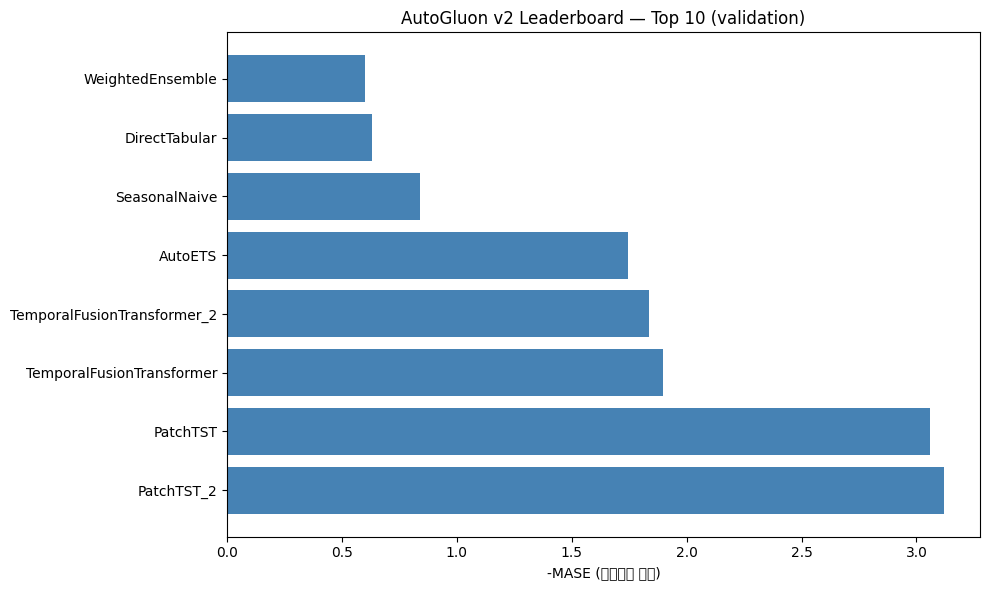

/tmp/ipykernel_1627/3979621777.py:26: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1627/3979621777.py:26: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1627/3979621777.py:26: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1627/3979621777.py:26: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1627/3979621777.py:26: UserWarning: Glyph 52649 (\N{HANGUL SYLLABLE CUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1627/3979621777.py:26: UserWarning: Glyph 52397 (\N{HANGUL SYLLABLE CEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1627/3979621777.py:26: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.ti

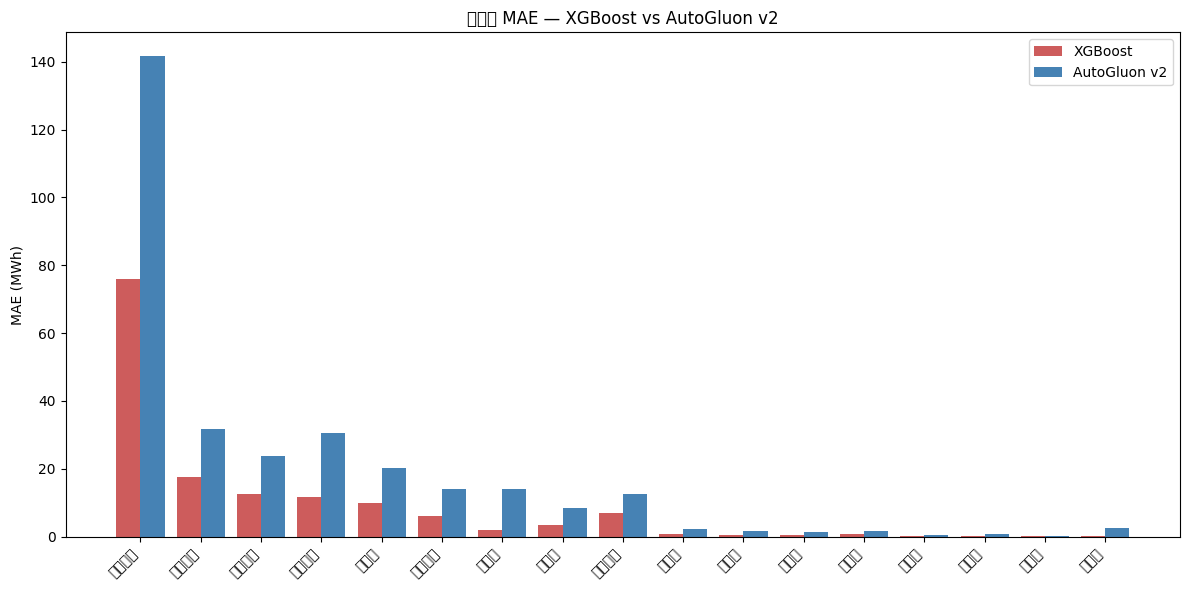


[15:09:09] ✅ 시각화 GCS 저장 완료


In [17]:
import matplotlib.pyplot as plt

# 그림 1: leaderboard
fig, ax = plt.subplots(figsize=(10, 6))
lb_top = leaderboard.head(10).copy()
ax.barh(lb_top["model"], -lb_top["score_val"], color="steelblue")
ax.set_xlabel(f"-{EVAL_METRIC} (낮을수록 좋음)")
ax.set_title("AutoGluon v2 Leaderboard — Top 10 (validation)")
ax.invert_yaxis()
plt.tight_layout()
LB_PNG = "/tmp/autogluon_v2_leaderboard.png"
plt.savefig(LB_PNG, dpi=120, bbox_inches="tight")
plt.show()

# 그림 2: 지역별 MAE 비교
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(compare))
w = 0.4
ax.bar(x - w/2, compare["mae_xgb"], w, label="XGBoost", color="indianred")
ax.bar(x + w/2, compare["mae_autogluon"], w, label="AutoGluon v2", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(compare["region"], rotation=45, ha="right")
ax.set_ylabel("MAE (MWh)")
ax.set_title("지역별 MAE — XGBoost vs AutoGluon v2")
ax.legend()
plt.tight_layout()
CMP_PNG = "/tmp/autogluon_v2_vs_xgb_region.png"
plt.savefig(CMP_PNG, dpi=120, bbox_inches="tight")
plt.show()

# GCS 업로드
try:
    fs.put(LB_PNG, f"{OUT_BASE}/autogluon_v2_leaderboard.png")
    fs.put(CMP_PNG, f"{OUT_BASE}/autogluon_v2_vs_xgb_region.png")
    print(f"\n{ts()} ✅ 시각화 GCS 저장 완료")
except Exception as e:
    print(f"⚠️ 시각화 GCS 저장 실패: {e}")


## 11. 결과 분기 진단


In [18]:
print(f"{ts()} === v2 결과 분기 진단 ===\n")

# v1 대비 개선 여부
v1_weighted_mae = 57.53
v2_improvement_pct = (v1_weighted_mae - ag_weighted) / v1_weighted_mae * 100

print(f"v1 가중 MAE : {v1_weighted_mae:.2f}")
print(f"v2 가중 MAE : {ag_weighted:.2f}")
print(f"v1 대비 개선: {v2_improvement_pct:+.1f}%\n")

# XGBoost 대비
xgb_diff_pct = (ag_weighted - xgb_weighted) / xgb_weighted * 100
print(f"XGBoost 가중 MAE: {xgb_weighted:.2f}")
print(f"AutoGluon v2 가중 MAE: {ag_weighted:.2f}")
print(f"XGBoost 대비: {xgb_diff_pct:+.1f}% (음수면 v2 우위)\n")

# 시나리오 판정
scenarios = []
if abs(xgb_diff_pct) <= 15:
    scenarios.append({
        "code": "a",
        "name": "모델 한계 확인 (XGBoost와 동등 수준)",
        "evidence": f"AutoGluon v2 가중 MAE {ag_weighted:.2f}, XGBoost 대비 ±15% 이내",
        "action": "Phase 2 MPC로 직행",
    })
if xgb_diff_pct < -15:
    scenarios.append({
        "code": "b",
        "name": "유의미한 개선",
        "evidence": f"AutoGluon v2가 XGBoost 대비 {-xgb_diff_pct:.1f}% 개선",
        "action": "AutoGluon 모델 1개 골라 심화",
    })
if xgb_diff_pct > 15:
    scenarios.append({
        "code": "?",
        "name": "AutoGluon v2도 XGBoost 못 이김",
        "evidence": f"AutoGluon v2가 XGBoost 대비 {xgb_diff_pct:.1f}% 악화",
        "action": "본인 XGBoost가 도메인 처방으로 잘 튜닝됐다는 추가 증거. Phase 2 MPC로 직행",
    })

for s in scenarios:
    print(f"📌 시나리오 ({s['code']}) — {s['name']}")
    print(f"   근거: {s['evidence']}")
    print(f"   다음 액션: {s['action']}\n")

# Top 모델 추천
print(f"=== Leaderboard Top 5 ===")
print(leaderboard.head(5).to_string(index=False))

print(f"\n{ts()} 🎉 v2 완료. 결과 보고 다음 단계 결정.")


[15:09:17] === v2 결과 분기 진단 ===

v1 가중 MAE : 57.53
v2 가중 MAE : 56.89
v1 대비 개선: +1.1%

XGBoost 가중 MAE: 29.55
AutoGluon v2 가중 MAE: 56.89
XGBoost 대비: +92.5% (음수면 v2 우위)

📌 시나리오 (?) — AutoGluon v2도 XGBoost 못 이김
   근거: AutoGluon v2가 XGBoost 대비 92.5% 악화
   다음 액션: 본인 XGBoost가 도메인 처방으로 잘 튜닝됐다는 추가 증거. Phase 2 MPC로 직행

=== Leaderboard Top 5 ===
                      model  score_val  pred_time_val  fit_time_marginal  fit_order
           WeightedEnsemble  -0.598623       3.107073           2.386336          8
              DirectTabular  -0.633194       3.045740         429.150904          2
              SeasonalNaive  -0.840452       0.059836           4.453532          1
                    AutoETS  -1.745625       4.335188          23.728409          3
TemporalFusionTransformer_2  -1.837518       0.726672         887.977376          5

[15:09:17] 🎉 v2 완료. 결과 보고 다음 단계 결정.


## 12. 로컬로 결과 가져오기

```bash
gsutil -m cp -r gs://solar-ess-portfolio/outputs/autogluon_v2 ./outputs/
```

## 다음 단계

| v2 결과 | 권장 액션 |
|---|---|
| XGBoost 대비 ±15% 이내 | **Phase 2 MPC 직행** (포트폴리오 메시지 강화) |
| XGBoost 대비 -15% 이상 개선 | 최상위 모델 1개 심화 (region embedding, lag dropout 등) |
| XGBoost 대비 +15% 이상 악화 | **Phase 2 MPC 직행** (본인 XGBoost 우위 증거) |

대부분 어느 시나리오든 **Phase 2 MPC**가 다음입니다. 본인 인수인계 문서 핵심 메시지("정확도-운영가치 격차") 기준.


In [19]:
import gcsfs
import os

fs = gcsfs.GCSFileSystem(project=PROJECT_ID)
os.makedirs("/content/results_v1", exist_ok=True)
os.makedirs("/content/results_v2", exist_ok=True)

# v2 받기
for f in fs.ls(f"gs://{GCS_BUCKET}/outputs/autogluon_v2/"):
    if "/" in f.rstrip("/").split("/")[-1]:  # 폴더 스킵
        continue
    fname = f.split("/")[-1]
    fs.get(f, f"/content/results_v2/{fname}")
    print(f"✅ v2: {fname}")

# v1 받기 (models 폴더 제외)
for f in fs.ls(f"gs://{GCS_BUCKET}/outputs/autogluon_v1/"):
    if f.endswith("/") or "models" in f.split("/")[-1]:
        continue  # models 폴더 스킵
    fname = f.split("/")[-1]
    fs.get(f, f"/content/results_v1/{fname}")
    print(f"✅ v1: {fname}")

# Zip으로 묶어서 한번에 다운로드
!cd /content && zip -r autogluon_results.zip results_v1 results_v2
print("\n다운로드: /content/autogluon_results.zip")

✅ v2: autogluon_v2_leaderboard.png
✅ v2: autogluon_v2_vs_xgb_region.png
✅ v2: leaderboard.csv
✅ v2: national_autogluon_v2_predictions.csv
✅ v2: national_autogluon_v2_region_comparison.csv
✅ v2: national_autogluon_v2_results.json
✅ v1: autogluon_leaderboard.png
✅ v1: autogluon_vs_xgb_region.png
✅ v1: leaderboard.csv
✅ v1: national_autogluon_predictions.csv
✅ v1: national_autogluon_region_mae.csv
✅ v1: national_autogluon_results.json
  adding: results_v1/ (stored 0%)
  adding: results_v1/autogluon_vs_xgb_region.png (deflated 28%)
  adding: results_v1/national_autogluon_predictions.csv (deflated 57%)
  adding: results_v1/autogluon_leaderboard.png (deflated 24%)
  adding: results_v1/national_autogluon_results.json (deflated 65%)
  adding: results_v1/national_autogluon_region_mae.csv (deflated 42%)
  adding: results_v1/leaderboard.csv (deflated 34%)
  adding: results_v2/ (stored 0%)
  adding: results_v2/national_autogluon_v2_predictions.csv (deflated 57%)
  adding: results_v2/autogluon_v2_v